In [1]:
import numpy as np 
import pandas as pd

df = pd.read_csv("athlete_events.csv")
region_df = pd.read_csv("noc_regions.csv")
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


In [2]:
df = df[df["Season"] != "Winter"]
df.shape
df.tail()
region_df.head()

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN


In [3]:
df = df.merge(region_df,on="NOC",how="left")

In [4]:
df.head(2)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN


In [5]:
df["region"].unique().shape
df.isnull().sum()
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [6]:
df = pd.concat([df,pd.get_dummies(df["Medal"])],axis=1)

In [7]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,False,False,False
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,False,False,False
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,False,False,False
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,False,True,False
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,False,False,False


In [8]:
df.groupby("region").sum(["Gold","Bronze","Silver"]).sort_values("Gold",ascending=False).reset_index()

,region,ID,Age,Height,Weight,Year,Bronze,Gold,Silver
0,USA,989946553,377596.0,2049657.0,804452.333333,29134834,1197,2472,1333
1,Russia,648031748,217623.0,1381581.0,563648.000000,17560428,994,1220,974
2,Germany,891724100,310667.0,1807882.0,731351.500000,24249146,1064,1075,987
3,UK,714239944,269302.0,1236282.0,493671.000000,21164202,620,635,729
4,Italy,492296861,201539.0,1053824.0,407626.000000,16113714,454,518,474
...,...,...,...,...,...,...,...,...,...
200,Lesotho,5872219,1644.0,8530.0,3168.000000,131788,0,0,0
201,Albania,4583008,1631.0,8635.0,3879.000000,126092,0,0,0
202,Libya,3745625,987.0,9771.0,4099.000000,167304,0,0,0
203,Liechtenstein,5627797,2361.0,13340.0,5485.000000,183936,0,0,0


In [9]:
medal_tally = df.drop_duplicates(subset=["Team","NOC","Games","Year","Season","City","Sport","Event","Medal"])
medal_tally

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,False,False,False
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,False,False,False
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,False,False,False
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,False,True,False
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222528,135553,Galina Ivanovna Zybina (-Fyodorova),F,25.0,168.0,80.0,Soviet Union,URS,1956 Summer,1956,Summer,Melbourne,Athletics,Athletics Women's Shot Put,Silver,Russia,NaN,False,False,True
222530,135553,Galina Ivanovna Zybina (-Fyodorova),F,33.0,168.0,80.0,Soviet Union,URS,1964 Summer,1964,Summer,Tokyo,Athletics,Athletics Women's Shot Put,Bronze,Russia,NaN,True,False,False
222536,135556,Bogusaw Stanisaw Zychowicz,M,19.0,189.0,80.0,Poland,POL,1980 Summer,1980,Summer,Moskva,Swimming,Swimming Men's 100 metres Butterfly,NaN,Poland,NaN,False,False,False
222537,135556,Bogusaw Stanisaw Zychowicz,M,19.0,189.0,80.0,Poland,POL,1980 Summer,1980,Summer,Moskva,Swimming,Swimming Men's 200 metres Butterfly,NaN,Poland,NaN,False,False,False


In [10]:
metal_tally = medal_tally.groupby("region").sum(["Gold","Bronze","Silver"]).sort_values("Gold",ascending=False).reset_index()

In [11]:
medal_tally["total"] = medal_tally["Gold"] + medal_tally["Silver"] + medal_tally["Bronze"]

C:\Users\DELL\AppData\Local\Temp\ipykernel_10252\3233527437.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  medal_tally["total"] = medal_tally["Gold"] + medal_tally["Silver"] + medal_tally["Bronze"]


In [12]:
year = df["Year"].unique().tolist()
year.sort()
year.insert(0,"Over All")
year

['Over All',
 1896,
 1900,
 1904,
 1906,
 1908,
 1912,
 1920,
 1924,
 1928,
 1932,
 1936,
 1948,
 1952,
 1956,
 1960,
 1964,
 1968,
 1972,
 1976,
 1980,
 1984,
 1988,
 1992,
 1996,
 2000,
 2004,
 2008,
 2012,
 2016]

In [13]:
country = np.unique(df["region"].dropna().values).tolist()
country.insert(0,"Over All")
country.sort()

In [14]:
medal_df =  df.drop_duplicates(subset=["Team","NOC","Games","Year","Season","City","Sport","Event","Medal"])

def fetch_medal_tally(year,country):
    
    medal_df =  df.drop_duplicates(subset=["Team","NOC","Games","Year","Season","City","Sport","Event","Medal"])
    medal_df_clean = medal_df.dropna(subset=["Medal"]).copy()
    medal_df_clean[["Gold", "Silver", "Bronze"]] = medal_df_clean[["Gold", "Silver", "Bronze"]].astype(int)

    flag = 0
    
    if year  == "Over All" and country == "Over All":
        temp_df = medal_df
        
    elif year == "Over All" and country != "Over All": 
        flag = 1
        temp_df = medal_df[medal_df["region"] == country]
    
    elif year != "Over All" and country == "Over All": 
        temp_df = medal_df[medal_df["Year"] == int(year)]
    
    elif year != "Over All" and country != "Over All": 
        temp_df = medal_df[(medal_df["region"] == country) & (medal_df["Year"] == int(year))]

    if flag ==1:
        x = temp_df.groupby("Year")[["Gold", "Silver", "Bronze"]].sum().sort_values("Year").reset_index()
    else:
        x = temp_df.groupby("region")[["Gold", "Silver", "Bronze"]].sum().sort_values("Gold", ascending=False).reset_index()
    x["total"] = x["Gold"] + x["Silver"] + x["Bronze"]

    print(x)

fetch_medal_tally(year="Over All",country="India")

    Year  Gold  Silver  Bronze  total
0   1900     0       2       0      2
1   1920     0       0       0      0
2   1924     0       0       0      0
3   1928     1       0       0      1
4   1932     1       0       0      1
5   1936     1       0       0      1
6   1948     1       0       0      1
7   1952     1       0       1      2
8   1956     1       0       0      1
9   1960     0       1       0      1
10  1964     1       0       0      1
11  1968     0       0       1      1
12  1972     0       0       1      1
13  1976     0       0       0      0
14  1980     1       0       0      1
15  1984     0       0       0      0
16  1988     0       0       0      0
17  1992     0       0       0      0
18  1996     0       0       1      1
19  2000     0       0       1      1
20  2004     0       1       0      1
21  2008     1       0       2      3
22  2012     0       2       4      6
23  2016     0       1       1      2


In [15]:
df["Year"].unique().shape[0] -1

28

In [16]:
df["City"].unique()

array(['Barcelona', 'London', 'Antwerpen', 'Paris', 'Los Angeles',
       'Helsinki', 'Sydney', 'Atlanta', 'Stockholm', 'Beijing',
       'Rio de Janeiro', 'Athina', 'Mexico City', 'Munich', 'Seoul',
       'Berlin', 'Melbourne', 'Roma', 'Amsterdam', 'Montreal', 'Moskva',
       'Tokyo', 'St. Louis'], dtype=object)

In [17]:
df["Sport"].unique()

array(['Basketball', 'Judo', 'Football', 'Tug-Of-War', 'Athletics',
       'Swimming', 'Badminton', 'Sailing', 'Gymnastics',
       'Art Competitions', 'Handball', 'Weightlifting', 'Wrestling',
       'Water Polo', 'Hockey', 'Rowing', 'Fencing', 'Equestrianism',
       'Shooting', 'Boxing', 'Taekwondo', 'Cycling', 'Diving', 'Canoeing',
       'Tennis', 'Modern Pentathlon', 'Golf', 'Softball', 'Archery',
       'Volleyball', 'Synchronized Swimming', 'Table Tennis', 'Baseball',
       'Rhythmic Gymnastics', 'Rugby Sevens', 'Trampolining',
       'Beach Volleyball', 'Triathlon', 'Rugby', 'Lacrosse', 'Polo',
       'Cricket', 'Ice Hockey', 'Racquets', 'Motorboating', 'Croquet',
       'Figure Skating', 'Jeu De Paume', 'Roque', 'Basque Pelota',
       'Alpinism', 'Aeronautics'], dtype=object)

In [18]:
nation_over_time = df.drop_duplicates(["Year","region"])["Year"].value_counts().reset_index().sort_values(["Year"])
nation_over_time.rename(columns={"count":"No of Countries"},inplace=True)

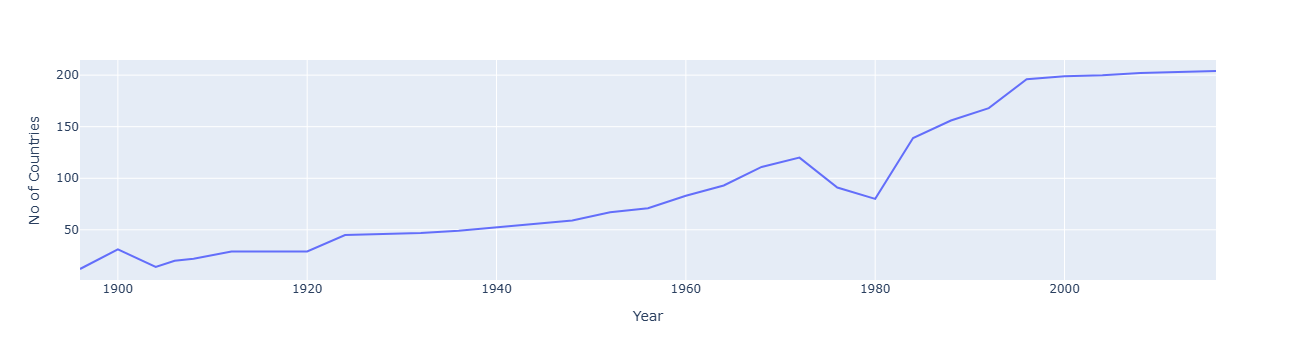

<Figure size 1200x800 with 0 Axes>

In [19]:
import plotly.express as px
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
fig = px.line(nation_over_time,x="Year",y="No of Countries")
fig.show()

In [20]:
df.drop_duplicates(["Year","Event"])["Year"].value_counts().reset_index().sort_values(["Year"])

,Year,count
28,1896,43
26,1900,90
25,1904,95
27,1906,74
23,1908,109
24,1912,107
14,1920,158
20,1924,131
22,1928,122
21,1932,131


<Axes: xlabel='Year', ylabel='Sport'>

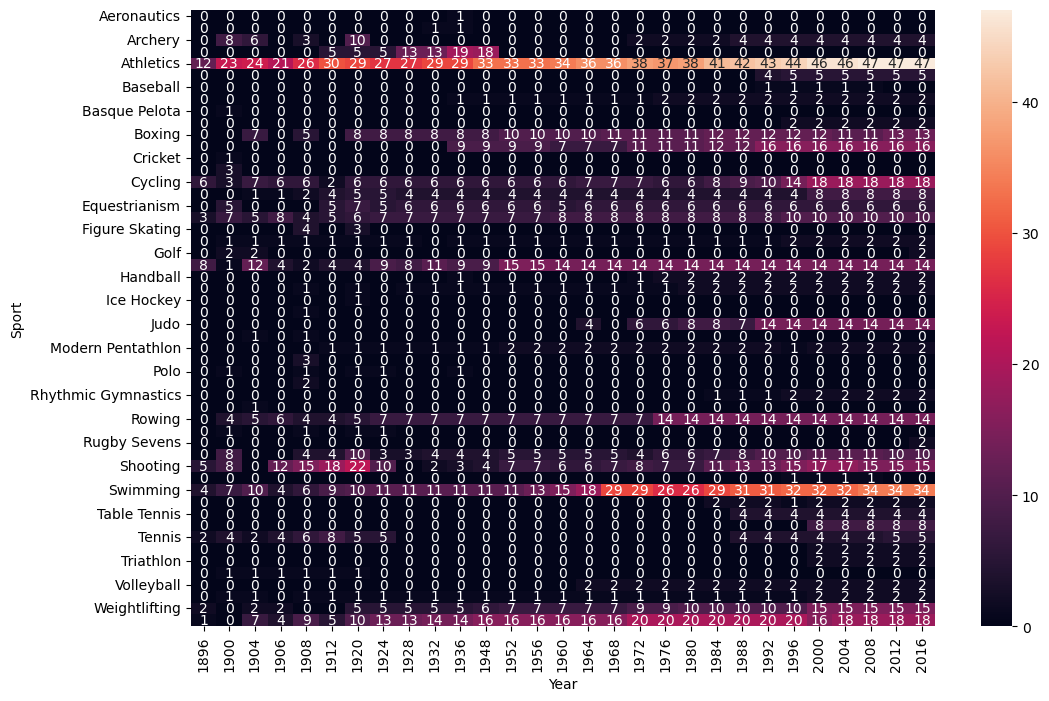

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

x = df.drop_duplicates(["Year","Sport","Event"])
plt.figure(figsize=(12,8))
sns.heatmap(x.pivot_table(index="Sport",columns="Year",values="Event",aggfunc="count").fillna(0).astype(int),annot=True) # nnot represent numbers

In [22]:
def most_wins(df,sport):
    
    temp_df = df.dropna(subset="Medal")
    if sport != "Over All":
        temp_df = temp_df[temp_df["Sport"] == sport]
    x = temp_df["Name"].value_counts().reset_index().head(15).merge(df,on="Name",how="left")
    x.rename(columns={"count":"Medals"},inplace=True)
    return x[["Name","Medals","Sport","region"]].drop_duplicates("Name")

In [23]:
most_wins(df,"Basketball")

,Name,Medals,Sport,region
0,Teresa Edwards,5,Basketball,USA
5,Kristi Lee Harrower,4,Basketball,Australia
9,Tamika Devonne Catchings,4,Basketball,USA
13,Gennady Georgiyevich Volnov,4,Basketball,Russia
17,"Suzanne Brigit ""Sue"" Bird",4,Basketball,USA
21,Lauren Elizabeth Jackson,4,Basketball,Australia
25,Sergey Aleksandrovich Belov,4,Basketball,Russia
29,Carmelo Kyan Anthony,4,Basketball,USA
33,Diana Lurena Taurasi,4,Basketball,USA
37,Lisa Deshawn Leslie (-Lockwood),4,Basketball,USA


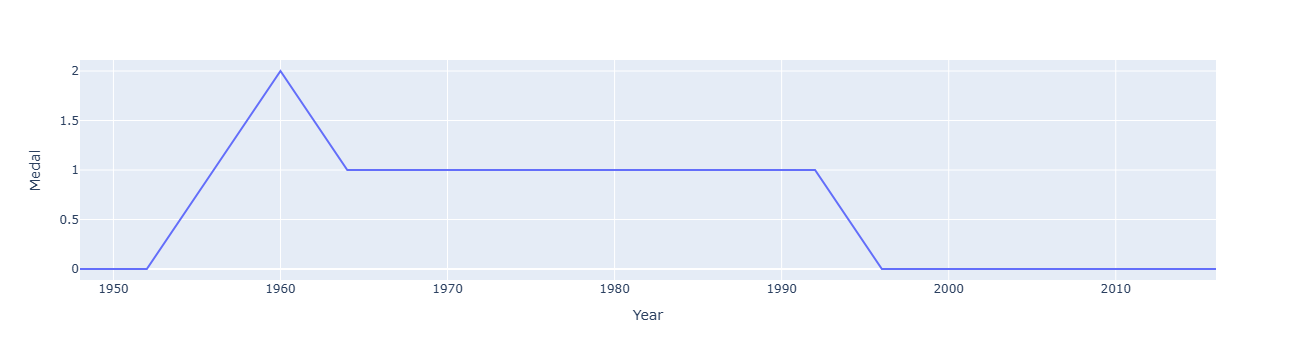

<Figure size 1200x800 with 0 Axes>

In [24]:
# Country Wise Analysis
temp_df = df.dropna(subset="Medal")
temp_df = df.drop_duplicates(subset=["Team","NOC","Games","Year","Season","City","Sport","Event","Medal"])
new_df = temp_df[temp_df["region"] == "Pakistan"]
final_df = new_df.groupby("Year").count()["Medal"].reset_index()
# final_df
plt.figure(figsize=(12,8))
fig = px.line(final_df,x="Year",y="Medal")
fig.show()

<Axes: xlabel='Year', ylabel='Sport'>

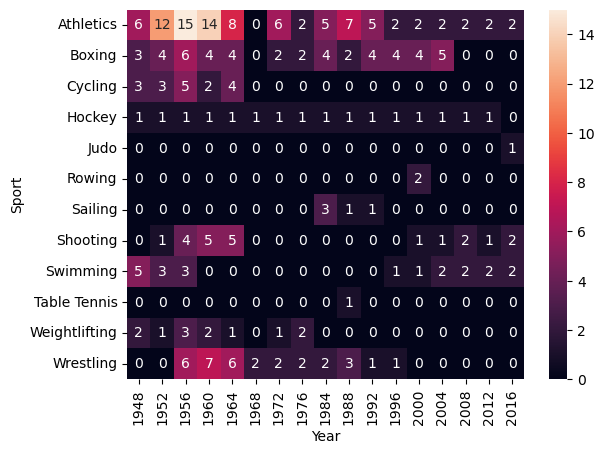

In [25]:
new_df = temp_df[temp_df["region"] == "Pakistan"]
sns.heatmap(new_df.pivot_table(index="Sport",columns="Year",values="Event",aggfunc="count").fillna(0).astype(int),annot=True)

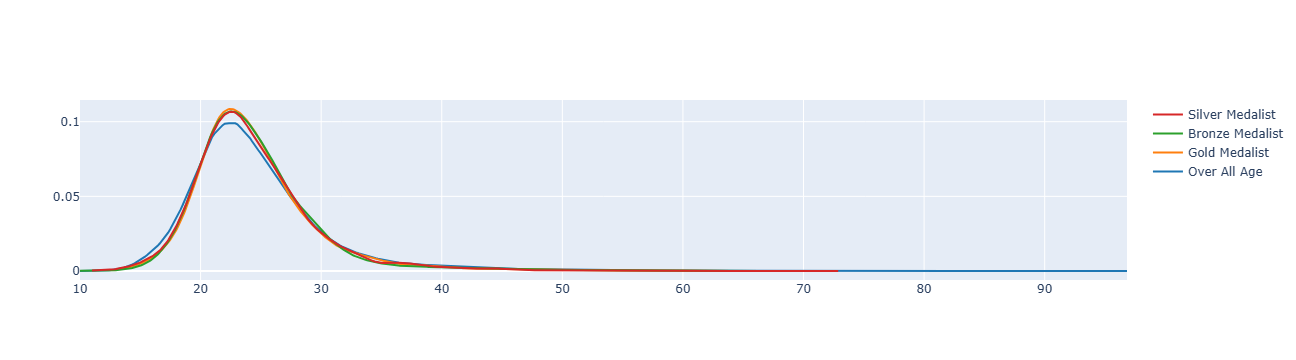

In [26]:
import plotly.figure_factory as ff
athelete_df = df.drop_duplicates(subset=["Name"])
x1 = athelete_df["Age"].dropna()
x2 = athelete_df[athelete_df["Medal"] == "Gold"]["Age"].dropna()
x3 = athelete_df[athelete_df["Medal"] == "Bronze"]["Age"].dropna()
x4 = athelete_df[athelete_df["Medal"] == "Silver"]["Age"].dropna()
fig = ff.create_distplot([x1,x2,x3,x4],["Over All Age","Gold Medalist","Bronze Medalist","Silver Medalist"],show_hist=False,show_rug=False)
fig.show()

In [27]:
athelete_df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,False,False,False
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,False,False,False
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,False,False,False
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,False,True,False
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222544,135563,Olesya Nikolayevna Zykina,F,19.0,171.0,64.0,Russia,RUS,2000 Summer,2000,Summer,Sydney,Athletics,Athletics Women's 4 x 400 metres Relay,Bronze,Russia,NaN,True,False,False
222546,135565,Fernando scar Zylberberg,M,23.0,168.0,76.0,Argentina,ARG,2000 Summer,2000,Summer,Sydney,Hockey,Hockey Men's Hockey,NaN,Argentina,NaN,False,False,False
222548,135566,"James Francis ""Jim"" Zylker",M,21.0,175.0,75.0,United States,USA,1972 Summer,1972,Summer,Munich,Football,Football Men's Football,NaN,USA,NaN,False,False,False
222549,135567,Aleksandr Viktorovich Zyuzin,M,24.0,183.0,72.0,Russia,RUS,2000 Summer,2000,Summer,Sydney,Rowing,Rowing Men's Lightweight Coxless Fours,NaN,Russia,NaN,False,False,False
